In [1]:
import pandas as pd
import random

names = ["Ravi","Priya","Kumar","Arun","Meena","Divya","Karthik","Suresh","Vijay","Anitha"]
cities = ["Chennai","Madurai","Coimbatore","Trichy","Salem","Tirunelveli","Thoothukudi"]
foods = ["Biryani","Pizza","Burger","Dosa","Fried Rice","Shawarma","Parotta","Noodles"]
payments = ["UPI","Card","Cash"]

data = []

for i in range(1000):
    data.append([
        1001+i,
        random.choice(names),
        random.choice(cities),
        f"2025-{random.randint(1,12):02d}-{random.randint(1,28):02d}",
        f"{random.randint(10,22):02d}:{random.randint(0,59):02d}",
        random.choice(foods),
        random.randint(1,5),
        random.randint(80,350),
        random.choice(payments),
        random.randint(1,5)
    ])

df = pd.DataFrame(data, columns=[
    "Order_ID","Customer_Name","City","Order_Date",
    "Order_Time","Food_Item","Quantity","Price",
    "Payment_Mode","Customer_Rating"
])

df.to_csv("food_orders.csv", index=False)

print("Dataset Created Successfully")
df.head()

Dataset Created Successfully


,Order_ID,Customer_Name,City,Order_Date,Order_Time,Food_Item,Quantity,Price,Payment_Mode,Customer_Rating
0,1001,Anitha,Trichy,2025-12-26,15:09,Noodles,2,293,Cash,3
1,1002,Ravi,Thoothukudi,2025-12-05,11:30,Noodles,5,288,UPI,1
2,1003,Ravi,Coimbatore,2025-03-23,11:53,Biryani,5,146,Cash,4
3,1004,Vijay,Salem,2025-08-07,11:29,Parotta,3,99,Cash,2
4,1005,Priya,Madurai,2025-03-07,12:06,Dosa,2,313,UPI,4


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Order_ID         1000 non-null   int64 
 1   Customer_Name    1000 non-null   object
 2   City             1000 non-null   object
 3   Order_Date       1000 non-null   object
 4   Order_Time       1000 non-null   object
 5   Food_Item        1000 non-null   object
 6   Quantity         1000 non-null   int64 
 7   Price            1000 non-null   int64 
 8   Payment_Mode     1000 non-null   object
 9   Customer_Rating  1000 non-null   int64 
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [4]:
df.isnull().sum()

,0
Order_ID,0
Customer_Name,0
City,0
Order_Date,0
Order_Time,0
Food_Item,0
Quantity,0
Price,0
Payment_Mode,0
Customer_Rating,0


In [5]:
df["Revenue"] = df["Quantity"] * df["Price"]
df.head()

,Order_ID,Customer_Name,City,Order_Date,Order_Time,Food_Item,Quantity,Price,Payment_Mode,Customer_Rating,Revenue
0,1001,Anitha,Trichy,2025-12-26,15:09,Noodles,2,293,Cash,3,586
1,1002,Ravi,Thoothukudi,2025-12-05,11:30,Noodles,5,288,UPI,1,1440
2,1003,Ravi,Coimbatore,2025-03-23,11:53,Biryani,5,146,Cash,4,730
3,1004,Vijay,Salem,2025-08-07,11:29,Parotta,3,99,Cash,2,297
4,1005,Priya,Madurai,2025-03-07,12:06,Dosa,2,313,UPI,4,626


In [6]:
total_revenue = df["Revenue"].sum()
print("Total Revenue =",total_revenue)

Total Revenue = 645510


In [14]:
payment_analysis = df["Payment_Mode"].value_counts()
print(payment_analysis)

Payment_Mode
UPI     360
Cash    329
Card    311
Name: count, dtype: int64


In [15]:
avg_rating = df["Customer_Rating"].mean()
print("Average Rating =",avg_rating)

Average Rating = 2.934


Text(0, 0.5, 'Count')

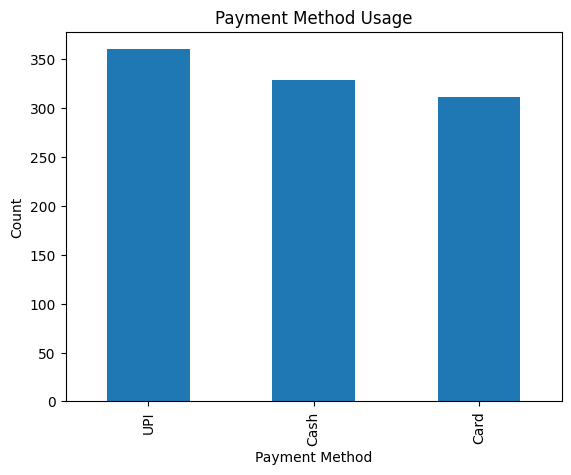

In [16]:
payment_analysis.plot(kind='bar')
plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Count")

In [9]:
popular_food = df.groupby("Food_Item")["Quantity"].sum()

print(popular_food)

Food_Item
Biryani       382
Burger        344
Dosa          347
Fried Rice    445
Noodles       375
Parotta       356
Pizza         392
Shawarma      384
Name: Quantity, dtype: int64


In [10]:
city_sales = df.groupby("City")["Revenue"].sum()
print(city_sales)

City
Chennai        95027
Coimbatore     92501
Madurai        96833
Salem          77681
Thoothukudi    89681
Tirunelveli    98176
Trichy         95611
Name: Revenue, dtype: int64


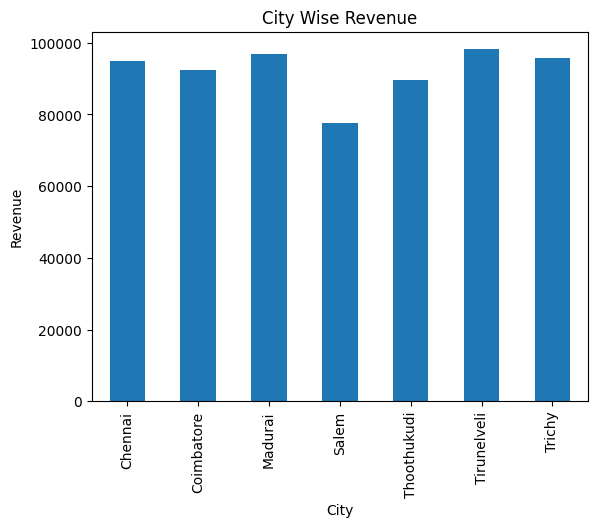

In [11]:
import matplotlib.pyplot as plt
city_sales.plot(kind='bar')
plt.title("City Wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

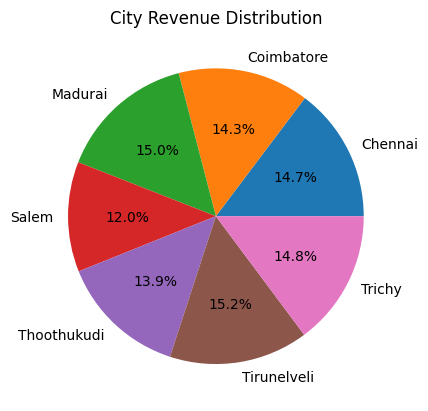

In [12]:
city_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title("City Revenue Distribution")
plt.ylabel("")
plt.show()

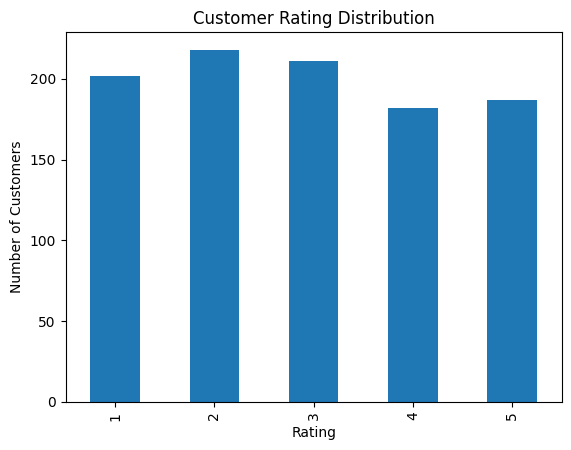

In [17]:
df["Customer_Rating"].value_counts().sort_index().plot(kind='bar')
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.show()

In [18]:
df.to_csv("Food_Delivery_Final.csv",index=False)
print("Final Dataset Saved")

Final Dataset Saved


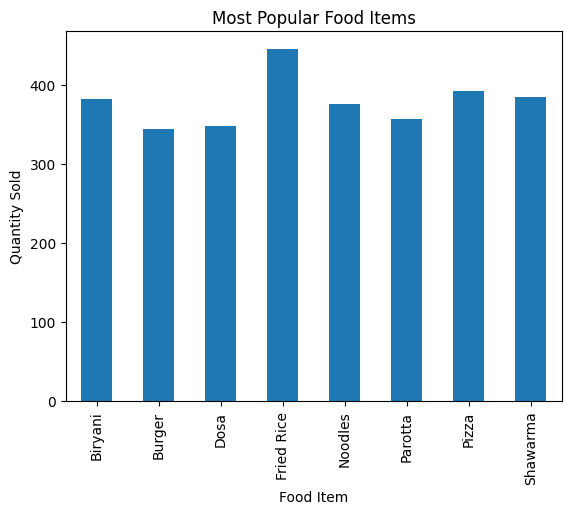

In [13]:
popular_food.plot(kind='bar')
plt.title("Most Popular Food Items")
plt.xlabel("Food Item")
plt.ylabel("Quantity Sold")
plt.show()